<a href="https://colab.research.google.com/github/si-mong/ComputerVision/blob/main/CV_HW3/%E1%84%89%E1%85%B5%E1%86%AF%E1%84%92%E1%85%A5%E1%86%B7A.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 실험 A — 손실 함수 비교: CrossEntropy Loss vs MSE Loss (with softmax)

**컴퓨터비전 과제 / TensorFlow (Google Colab)**

---

## 1) 실험 목표
- **MSE Loss**와 **CrossEntropy Loss**가 분류 학습 성능에 미치는 차이를 정량적으로 분석한다.
- 학습 곡선의 **수렴 속도 / 최종 정확도 / Loss 안정성**을 비교한다.
- MSE 사용 시 발생하는 **Gradient Vanishing** 현상을 gradient norm 추적으로 정량적으로 확인한다.

## 2) 데이터셋
- **Fashion-MNIST** (28×28 흑백 이미지, 10 클래스). 입력은 784차원 벡터로 flatten 후 [0, 1] 정규화.

## 3) 실험 조건 (통제 변수)
| 항목 | 설정 |
|---|---|
| 네트워크 | MLP: 784 → 256(ReLU) → 128(ReLU) → 10(logits) |
| Optimizer | SGD (lr = 0.1) — 세 실험 동일 |
| Epoch | 30 |
| Batch size | 64 |
| 가중치 초기화 | 동일 시드(2025)로 고정 → 재현성 확보 |
| **변경 변수** | **손실 함수만** (CrossEntropy vs MSE w/ softmax vs MSE raw) |

> **핵심 구현 포인트**
> - 출력층은 **logits** (activation=None) 으로 둔다.
> - **CrossEntropy**: `from_logits=True` → 내부적으로 softmax 포함, 별도 softmax 불필요.
> - **MSE (softmax)**: 출력층 뒤에 `tf.nn.softmax`를 **명시적으로** 적용한 뒤 one-hot 타깃과 MSE 계산.
> - **MSE (raw)**: softmax 없이 raw logits와 one-hot을 직접 MSE 비교 → 학습 불안정 대조군.


## 4) 환경 설정 및 라이브러리 임포트

In [ ]:
# ── 라이브러리 임포트 ─────────────────────────────────────────────────────
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import time
from dataclasses import dataclass, field
from typing import List, Dict, Optional

# ── 재현성: 모든 난수 시드 고정 (평가기준 1: 동일 조건 재현성) ───────────────
SEED = 2025
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


## 5) 실험 설정 (ExperimentConfig)
하이퍼파라미터를 한 곳에 모아 명확히 기록한다 (평가기준 1).

In [ ]:
@dataclass
class ExperimentConfig:
    img_input_dim: int   = 28 * 28   # Fashion-MNIST 입력 차원 (flatten)
    n_classes: int       = 10         # 출력 클래스 수
    batch_size: int      = 64
    n_epochs: int        = 30         # Fashion-MNIST 권장 범위 20~50
    learning_rate: float = 0.1        # SGD 가이드 범위 상한 (raw MSE의 logits 폭주 유도용)
    convergence_threshold: float = 0.85  # Val Acc 수렴 판정 임계값
    seed: int            = 2025

CFG = ExperimentConfig()
print(CFG)

ExperimentConfig(img_input_dim=784, n_classes=10, batch_size=64, n_epochs=30, learning_rate=0.1, convergence_threshold=0.85, seed=2025)


## 6) 데이터 로드 및 전처리

Fashion-MNIST를 불러와 다음을 수행한다.
- 28×28 이미지를 **784차원 벡터로 flatten**
- 픽셀값을 **[0, 1] 로 정규화** (학습 안정화)
- 라벨을 **one-hot 인코딩** — MSE는 연속값 타깃이 필요하고, CCE도 동일 타깃을 써서 조건 통일

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
train: (60000, 784)   test: (10000, 784)
one-hot label: (60000, 10)


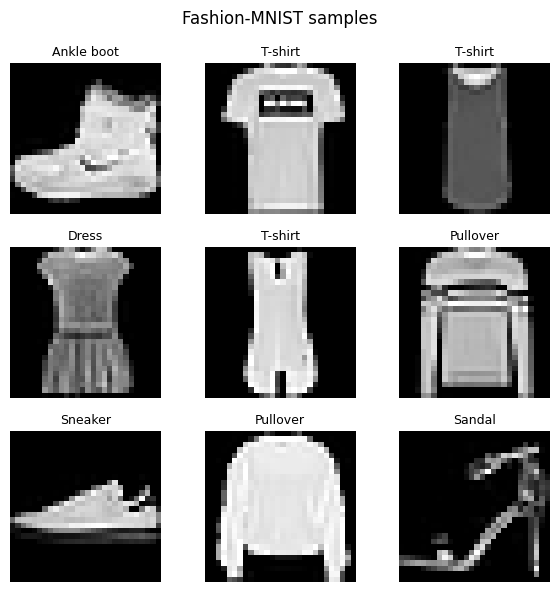

In [ ]:
# ── Fashion-MNIST 로드 및 전처리 ──────────────────────────────────────────
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

CLASS_NAMES = ['T-shirt', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# flatten + [0,1] 정규화
x_train = x_train.reshape(-1, 784).astype('float32') / 255.0
x_test  = x_test.reshape(-1,  784).astype('float32') / 255.0

# one-hot 인코딩 (MSE / CCE 공통 타깃 — 통제 조건)
y_train_oh = tf.keras.utils.to_categorical(y_train, CFG.n_classes)
y_test_oh  = tf.keras.utils.to_categorical(y_test,  CFG.n_classes)

print("train:", x_train.shape, "  test:", x_test.shape)
print("one-hot label:", y_train_oh.shape)

# ── 샘플 시각화 ─────────────────────────────────────────────────────────────
plt.figure(figsize=(6, 6))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(x_train[i].reshape(28, 28), cmap='gray')
    plt.title(CLASS_NAMES[y_train[i]], fontsize=9)
    plt.axis('off')
plt.suptitle('Fashion-MNIST samples')
plt.tight_layout()
plt.show()

## 7) 모델 정의

두 실험에서 **완전히 동일한 구조**의 모델을 사용한다. `build_model()` 함수로 매번 새 모델을 만들되,
호출 직전 시드를 재고정해 **초기 가중치가 동일**하도록 한다 → 손실 함수 외 변수 통제.

출력층 activation 을 `None` (logits) 으로 둔 이유:
- CCE 는 `from_logits=True` 로 logits 를 직접 받는 것이 수치적으로 안정적이다.
- MSE 는 이후 셀에서 softmax 를 **명시적으로** 적용한다.

In [ ]:
def build_model():
    """MLP: 784 -> 256(ReLU) -> 128(ReLU) -> 10(logits).
    출력층 activation=None -> raw logits 반환.
    호출마다 시드를 재고정하여 초기 가중치 동일 보장."""
    tf.random.set_seed(CFG.seed)
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(CFG.img_input_dim,)),
        tf.keras.layers.Dense(256, activation="relu", name="hidden1"),
        tf.keras.layers.Dense(128, activation="relu", name="hidden2"),
        tf.keras.layers.Dense(CFG.n_classes, activation=None, name="logits"),
    ])
    return model

build_model().summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden1 (Dense)                 │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ logits (Dense)                  │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 235,146 (918.54 KB)

 Trainable params: 235,146 (918.54 KB)

 Non-trainable params: 0 (0.00 B)

## 8) 손실 계산 모드 정의

3 가지 비교군:
1. `"ce"` — CrossEntropy (`from_logits=True`, 내부 softmax 포함)
2. `"mse_softmax"` — MSE + 명시적 softmax 적용
3. `"mse_raw"` — MSE + softmax 없음 (대조군, 학습 불안정 유도 목적)

In [ ]:
# ── 손실 함수 객체 (명시적으로 설정 — 과제 조건 C) ───────────────────────────
# CCE: from_logits=True -> logits 를 그대로 입력하면 내부에서 log-softmax 처리
# MSE: softmax 가 내장되지 않음 -> compute_loss 에서 직접 softmax 를 적용해야 함
cce_loss_fn = tf.keras.losses.CategoricalCrossentropy(from_logits=True)
mse_loss_fn = tf.keras.losses.MeanSquaredError()


def compute_loss(loss_mode: str, logits, y_onehot):
    """loss_mode 에 따라 손실을 계산한다.
    - 'ce'          : logits -> (내부 softmax) -> CrossEntropy
    - 'mse_softmax' : softmax 를 명시적으로 적용한 확률분포와 one-hot 간 MSE
    - 'mse_raw'     : softmax 없이 raw logits 와 one-hot 간 MSE (대조군)
    """
    if loss_mode == "ce":
        # CrossEntropy 는 logits 그대로 — from_logits=True 가 내부 softmax 처리
        return cce_loss_fn(y_onehot, logits)
    elif loss_mode == "mse_softmax":
        # MSE 사용 시 softmax 를 출력층에 명시적으로 적용 (과제 조건)
        probs = tf.nn.softmax(logits, axis=1)
        return mse_loss_fn(y_onehot, probs)
    elif loss_mode == "mse_raw":
        # Ablation: softmax 미적용 -> raw logits 를 그대로 MSE 에 투입
        # logits 는 (-inf, inf) 범위인데 타깃은 {0,1} -> 스케일 불일치로 학습 불안정
        return mse_loss_fn(y_onehot, logits)
    else:
        raise ValueError(f"알 수 없는 손실 모드: {loss_mode}")


def accuracy_from_logits(logits, y_int) -> float:
    """logits -> argmax -> 정수 라벨과 비교한 정확도.
    argmax 는 단조변환(softmax) 에 불변 -> softmax 적용 여부와 무관하게 동일 예측.
    """
    preds = tf.argmax(logits, axis=1, output_type=tf.int32)
    return tf.reduce_mean(tf.cast(preds == y_int, tf.float32)).numpy()

## 9) 학습 기록 및 Activation Recorder

친구 코드의 `TrainingLog` / `ActivationRecorder` dataclass 구조를 TF 용으로 포팅.
레이어별 gradient norm 을 별도 추적하여 **Gradient Vanishing 정량 분석**에 활용한다.

In [ ]:
# ── 학습 로그 dataclass ────────────────────────────────────────────────────
@dataclass
class TrainingLog:
    train_losses:    List[float] = field(default_factory=list)
    train_accs:      List[float] = field(default_factory=list)
    val_losses:      List[float] = field(default_factory=list)
    val_accs:        List[float] = field(default_factory=list)
    # 레이어별 gradient L2 norm (Gradient Vanishing 분석용)
    grad_norms_h1:   List[float] = field(default_factory=list)  # hidden1
    grad_norms_h2:   List[float] = field(default_factory=list)  # hidden2
    grad_norms_out:  List[float] = field(default_factory=list)  # output(logits)
    # gradient 분포 스냅샷 (초기/후반 시점)
    grad_snapshots:  Dict = field(default_factory=dict)
    convergence_epoch: Optional[int] = None
    total_time:      float = 0.0


# ── Activation Recorder ─────────────────────────────────────────────────────
# PyTorch 의 register_forward_hook 대신,
# TF 에서는 학습 루프 내부에서 직접 intermediate layer 출력을 계산해 저장한다.
class ActivationRecorder:
    """특정 epoch 에서 hidden layer 의 ReLU 출력 분포를 캡처하는 클래스."""

    def __init__(self):
        # {epoch_tag: {'hidden1': ndarray, 'hidden2': ndarray}}
        self.captured: Dict[str, Dict[str, 'np.ndarray']] = {}

    def record(self, tag: str, model, x_sample):
        """model 의 hidden1 / hidden2 출력을 tag 시점으로 저장.
        Args:
            tag: epoch 단계 식별자 ('early', 'mid', 'late')
            model: 학습 중인 tf.keras.Sequential 모델
            x_sample: 활성화를 추출할 입력 데이터 샘플
        """
        h1_out = model.get_layer('hidden1')(x_sample, training=False).numpy()
        h2_in  = model.get_layer('hidden1')(x_sample, training=False)
        h2_out = model.get_layer('hidden2')(h2_in, training=False).numpy()
        self.captured[tag] = {
            'hidden1': h1_out.flatten(),
            'hidden2': h2_out.flatten(),
        }

    def zero_ratio(self, tag: str, layer: str) -> float:
        """해당 시점·레이어에서 zero(dead neuron) 비율(%) 반환."""
        vals = self.captured.get(tag, {}).get(layer, np.array([]))
        if len(vals) == 0:
            return 0.0
        return (vals == 0).mean() * 100.0

## 10) 수동 학습 루프 정의

과제 조건에 따라 `model.fit()` 대신 **`for epoch in range(...)` 형태의 수동 학습 루프**를 작성한다.
- `tf.GradientTape()` 로 순전파를 기록하고 `tape.gradient()` 로 역전파(autograd) 를 수행한다.
- `loss_mode` 인자로 손실 함수를 **수동 교체**한다 (`"ce"` / `"mse_softmax"` / `"mse_raw"`).
- 매 epoch 마다 레이어별 **gradient norm** 을 기록 → MSE 의 Gradient Vanishing 정량 관찰.
- 평가 시 `training=False` 로 호출(추론 모드) — PyTorch 의 `model.eval()` + `torch.no_grad()` 에 해당.

In [ ]:
# ── @tf.function 컴파일된 학습 스텝 (eager 대비 가속) ──────────────────────
@tf.function
def _train_step(model, optimizer, loss_mode, xb, yb_oh):
    """한 미니배치: 순전파 -> 손실 계산 -> 역전파(autograd) -> 가중치 갱신."""
    with tf.GradientTape() as tape:
        logits = model(xb, training=True)                   # 순전파
        loss   = compute_loss(loss_mode, logits, yb_oh)     # 손실 계산
    grads = tape.gradient(loss, model.trainable_variables)  # 역전파: tape.gradient()
    optimizer.apply_gradients(zip(grads, model.trainable_variables))  # 가중치 갱신
    return loss, grads


# ── @tf.function 컴파일된 추론 스텝 ─────────────────────────────────────────
# training=False = 추론 모드 (Dropout/BatchNorm 비활성화)
# PyTorch 의 model.eval() + torch.no_grad() 와 동일한 역할
@tf.function
def _forward(model, x):
    return model(x, training=False)


def run_training_loop(loss_mode: str, cfg, activation_recorder=None):
    """수동 학습 루프 (@tf.function 가속).
    손실 함수(loss_mode) 만 교체하고 모델·옵티마이저·시드는 모두 동일하게 통제.
    Args:
        loss_mode: 'ce' / 'mse_softmax' / 'mse_raw'
        cfg: ExperimentConfig 하이퍼파라미터
        activation_recorder: ActivationRecorder 인스턴스 (None 이면 미사용)
    Returns:
        (TrainingLog, 학습된 model)
    """
    # ── 모델·옵티마이저 초기화 (동일 시드 -> 동일 초기 가중치 보장) ─────────
    model     = build_model()
    # SGD 선택 이유: CE vs MSE 차이가 이론대로 뚜렷이 드러나도록
    # (Adam 을 쓰면 MSE 도 너무 잘 학습되어 차이가 희석됨)
    optimizer = tf.keras.optimizers.SGD(learning_rate=cfg.learning_rate)
    optimizer.build(model.trainable_variables)  # 슬롯 변수 미리 생성

    log = TrainingLog()

    # ── 데이터 파이프라인 (셔플 시드 고정 -> 재현성 확보) ─────────────────
    train_ds = (
        tf.data.Dataset
        .from_tensor_slices((x_train, y_train_oh))
        .shuffle(10000, seed=cfg.seed)
        .batch(cfg.batch_size)
    )

    # Activation 캡처 시점: 초반/중반/후반
    capture_epochs = {
        1:                 'early',
        cfg.n_epochs // 2: 'mid',
        cfg.n_epochs:      'late',
    }

    y_train_int = tf.constant(y_train, dtype=tf.int32)
    y_test_int  = tf.constant(y_test,  dtype=tf.int32)

    print(f'\n[{loss_mode}] 학습 시작 - 총 {cfg.n_epochs} 에폭')
    t0 = time.time()

    for epoch in range(1, cfg.n_epochs + 1):
        h1_norms, h2_norms, out_norms = [], [], []

        # ── 미니배치 학습 (@tf.function 스텝 호출) ──────────────────────
        for xb, yb_oh in train_ds:
            loss, grads = _train_step(model, optimizer, loss_mode, xb, yb_oh)

            # trainable_variables 순서:
            # [h1.kernel, h1.bias, h2.kernel, h2.bias, out.kernel, out.bias]
            if grads[0] is not None:
                h1_norms.append(tf.norm(grads[0]).numpy())   # hidden1 kernel grad
            if grads[2] is not None:
                h2_norms.append(tf.norm(grads[2]).numpy())   # hidden2 kernel grad
            if grads[4] is not None:
                out_norms.append(tf.norm(grads[4]).numpy())  # output kernel grad

        # ── gradient 스냅샷 저장 (초기/후반 분포 비교용) ────────────────
        if epoch in (1, cfg.n_epochs) and grads[4] is not None:
            log.grad_snapshots[epoch] = grads[4].numpy().flatten()

        # ── 전체 데이터 평가 (training=False — 추론 모드) ───────────────
        train_logits = _forward(model, x_train)
        test_logits  = _forward(model, x_test)

        tr_loss = compute_loss(loss_mode, train_logits, y_train_oh).numpy()
        te_loss = compute_loss(loss_mode, test_logits,  y_test_oh ).numpy()
        tr_acc  = accuracy_from_logits(train_logits, y_train_int)
        te_acc  = accuracy_from_logits(test_logits,  y_test_int)

        log.train_losses.append(float(tr_loss))
        log.train_accs.append(float(tr_acc))
        log.val_losses.append(float(te_loss))
        log.val_accs.append(float(te_acc))
        log.grad_norms_h1.append(float(np.mean(h1_norms))   if h1_norms  else 0.0)
        log.grad_norms_h2.append(float(np.mean(h2_norms))   if h2_norms  else 0.0)
        log.grad_norms_out.append(float(np.mean(out_norms)) if out_norms else 0.0)

        # 수렴 epoch 자동 판정 (Val Acc 가 임계값 처음 돌파한 시점)
        if log.convergence_epoch is None and te_acc >= cfg.convergence_threshold:
            log.convergence_epoch = epoch

        # Activation 스냅샷 캡처 (초/중/후반 시점)
        if activation_recorder is not None and epoch in capture_epochs:
            tag = capture_epochs[epoch]
            activation_recorder.record(tag, model, x_test[:1000])

        print(f'  Ep {epoch:2d}/{cfg.n_epochs} | '
              f'Train Loss {tr_loss:.4f}  Acc {tr_acc:.4f} | '
              f'Val Loss {te_loss:.4f}  Acc {te_acc:.4f}')

    log.total_time = time.time() - t0
    print(f'  → 학습 완료 ({log.total_time:.1f}초)')
    if log.convergence_epoch is not None:
        print(f'  → 수렴 epoch: {log.convergence_epoch} '
              f'(Val Acc {cfg.convergence_threshold*100:.0f}% 돌파)')
    else:
        print(f'  → {cfg.convergence_threshold*100:.0f}% 미수렴')

    return log, model

## 11) 실험 실행 — CrossEntropy vs MSE(softmax) vs MSE(raw)

In [ ]:
# ── 비교할 손실 모드 리스트 ──────────────────────────────────────────────────
loss_modes_to_run = ['ce', 'mse_softmax', 'mse_raw']
mode_display_names = {
    'ce':           'CrossEntropy',
    'mse_softmax':  'MSE (with Softmax)',
    'mse_raw':      'MSE (no Softmax, Ablation)',
}

all_logs:        Dict[str, TrainingLog]        = {}
all_activations: Dict[str, ActivationRecorder] = {}
all_models  = {}

for mode in loss_modes_to_run:
    print(f'\n{"="*60}')
    print(f'실험: {mode_display_names[mode]}')
    print(f'{"="*60}')

    # 매 실험마다 시드 재고정 (재현성 보장)
    np.random.seed(CFG.seed)
    tf.random.set_seed(CFG.seed)

    recorder = ActivationRecorder()
    log, model = run_training_loop(mode, CFG, activation_recorder=recorder)

    all_logs[mode]        = log
    all_activations[mode] = recorder
    all_models[mode]      = model


실험: CrossEntropy

[ce] 학습 시작 - 총 30 에폭
  Ep  1/30 | Train Loss 0.4294  Acc 0.8409 | Val Loss 0.4628  Acc 0.8300
  Ep  2/30 | Train Loss 0.4058  Acc 0.8490 | Val Loss 0.4491  Acc 0.8368
  Ep  3/30 | Train Loss 0.4256  Acc 0.8375 | Val Loss 0.4790  Acc 0.8201
  Ep  4/30 | Train Loss 0.3572  Acc 0.8688 | Val Loss 0.4210  Acc 0.8499
  Ep  5/30 | Train Loss 0.2775  Acc 0.8982 | Val Loss 0.3422  Acc 0.8746
  Ep  6/30 | Train Loss 0.3230  Acc 0.8770 | Val Loss 0.3879  Acc 0.8550
  Ep  7/30 | Train Loss 0.2892  Acc 0.8910 | Val Loss 0.3658  Acc 0.8673
  Ep  8/30 | Train Loss 0.2634  Acc 0.9036 | Val Loss 0.3435  Acc 0.8748
  Ep  9/30 | Train Loss 0.2495  Acc 0.9057 | Val Loss 0.3379  Acc 0.8770
  Ep 10/30 | Train Loss 0.2567  Acc 0.9036 | Val Loss 0.3485  Acc 0.8770
  Ep 11/30 | Train Loss 0.2724  Acc 0.8982 | Val Loss 0.3645  Acc 0.8696
  Ep 12/30 | Train Loss 0.2151  Acc 0.9204 | Val Loss 0.3158  Acc 0.8842
  Ep 13/30 | Train Loss 0.2379  Acc 0.9088 | Val Loss 0.3402  Acc 0.8726
  Ep 14/30 

## 12) 정량적 분석 (표)

In [ ]:
# ── 정량 비교표 출력 ─────────────────────────────────────────────────────────
print('\n' + '='*95)
print(f"{'손실 함수':<30} | {'최종 정확도(%)':<14} | {'Loss 최솟값':<13} | {'수렴 epoch':<12} | 학습 시간(s)")
print('-'*95)
for mode in loss_modes_to_run:
    log = all_logs[mode]
    name      = mode_display_names[mode]
    final_acc = log.val_accs[-1] * 100
    min_loss  = min(log.val_losses)
    conv_ep   = str(log.convergence_epoch) if log.convergence_epoch else '미수렴'
    print(f'{name:<30} | {final_acc:<14.2f} | {min_loss:<13.4f} | {conv_ep:<12} | {log.total_time:.1f}')
print('='*95)

# pandas 사용 가능 시 DataFrame 으로도 출력
try:
    import pandas as pd
    rows = []
    for mode in loss_modes_to_run:
        log = all_logs[mode]
        rows.append({
            '손실 함수':        mode_display_names[mode],
            '최종 정확도 (%)':  round(log.val_accs[-1] * 100, 2),
            'Loss 최솟값':      round(min(log.val_losses), 4),
            '수렴 epoch':       log.convergence_epoch if log.convergence_epoch else '미수렴',
            '학습 시간 (s)':    round(log.total_time, 1),
        })
    df = pd.DataFrame(rows)
    display(df)
except Exception:
    pass


손실 함수                          | 최종 정확도(%)      | Loss 최솟값      | 수렴 epoch     | 학습 시간(s)
-----------------------------------------------------------------------------------------------
CrossEntropy                   | 86.81          | 0.3036        | 5            | 107.1
MSE (with Softmax)             | 86.01          | 0.0196        | 16           | 106.8
MSE (no Softmax, Ablation)     | 87.18          | 0.0208        | 8            | 104.2


,손실 함수,최종 정확도 (%),Loss 최솟값,수렴 epoch,학습 시간 (s)
0,CrossEntropy,86.81,0.3036,5,107.1
1,MSE (with Softmax),86.01,0.0196,16,106.8
2,"MSE (no Softmax, Ablation)",87.18,0.0208,8,104.2


## 13) 그래프 및 시각화 결과

### 13-1) Loss / Accuracy 학습 곡선 오버레이 비교

세 손실 모드의 Loss / Accuracy 곡선을 같은 축에 겹쳐 그려 직관적 비교.
Loss 는 스케일이 달라 손실 함수별 개별 패널, Accuracy 는 동일 척도로 비교.

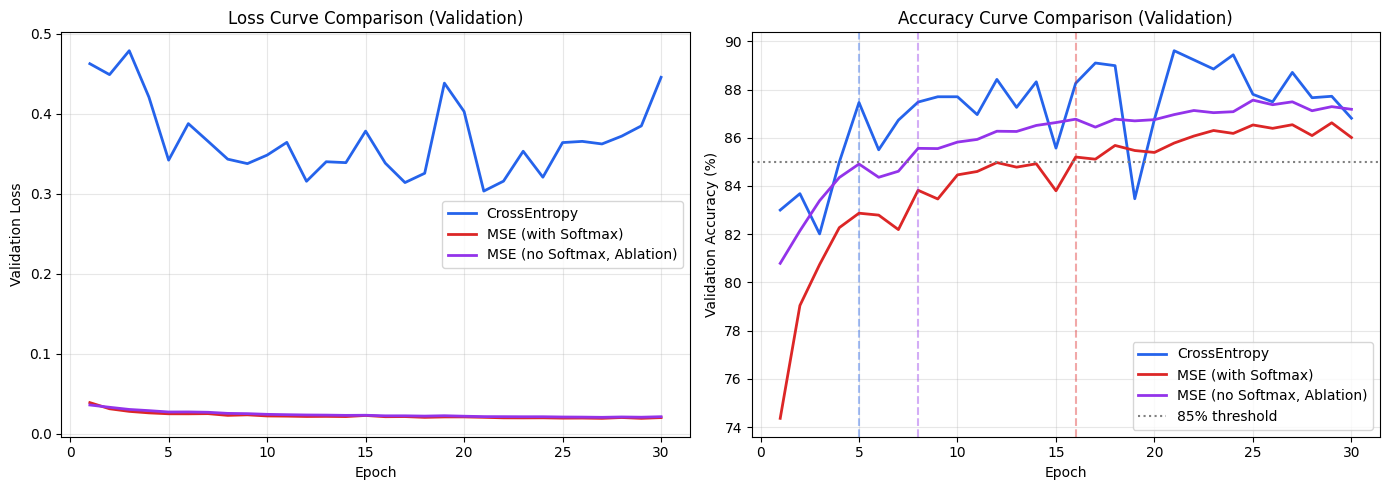

In [ ]:
color_palette = {'ce': '#2563EB', 'mse_softmax': '#DC2626', 'mse_raw': '#9333EA'}
ep = range(1, CFG.n_epochs + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (1) Validation Loss 비교
for mode in loss_modes_to_run:
    log = all_logs[mode]
    axes[0].plot(ep, log.val_losses,
                 label=mode_display_names[mode],
                 color=color_palette[mode], linewidth=2)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Validation Loss')
axes[0].set_title('Loss Curve Comparison (Validation)')
axes[0].legend(); axes[0].grid(alpha=0.3)

# (2) Validation Accuracy 비교 + 수렴 시점 표시
for mode in loss_modes_to_run:
    log = all_logs[mode]
    axes[1].plot(ep, [a * 100 for a in log.val_accs],
                 label=mode_display_names[mode],
                 color=color_palette[mode], linewidth=2)
    if log.convergence_epoch is not None:
        axes[1].axvline(x=log.convergence_epoch,
                        color=color_palette[mode], linestyle='--', alpha=0.4)

axes[1].axhline(y=CFG.convergence_threshold * 100, color='gray',
                linestyle=':', label=f'{CFG.convergence_threshold*100:.0f}% threshold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Validation Accuracy (%)')
axes[1].set_title('Accuracy Curve Comparison (Validation)')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 13-2) 각 손실 모드별 Train vs Validation 곡선

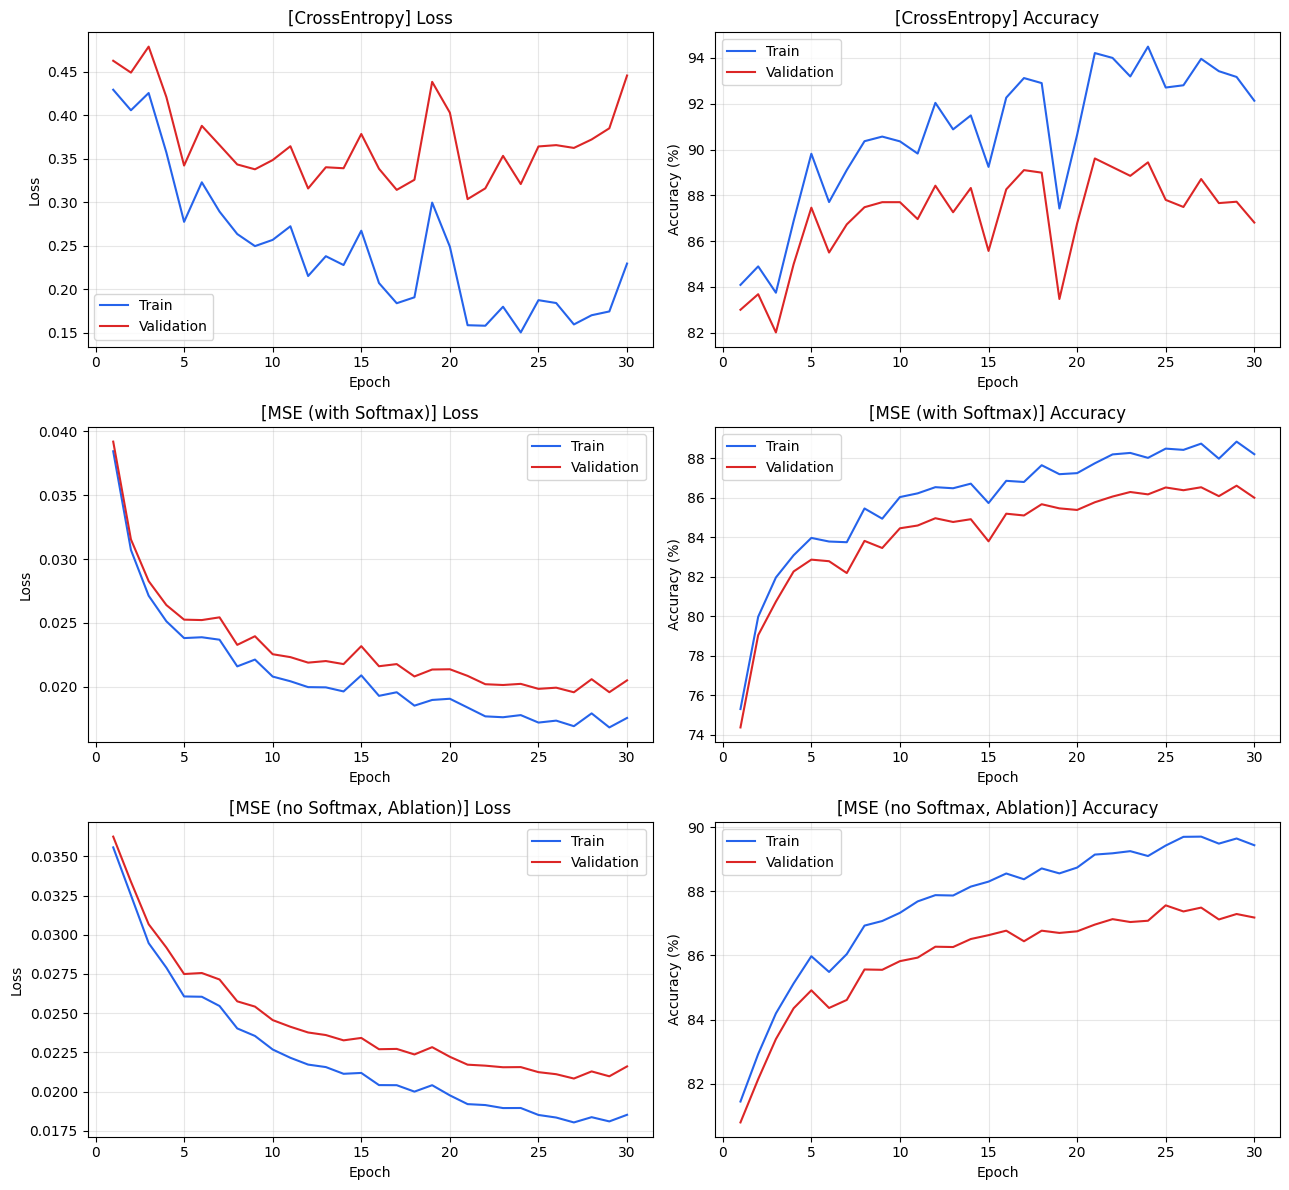

In [ ]:
fig, axes = plt.subplots(len(loss_modes_to_run), 2,
                          figsize=(13, 4 * len(loss_modes_to_run)))

for row, mode in enumerate(loss_modes_to_run):
    log = all_logs[mode]

    axes[row, 0].plot(ep, log.train_losses, label='Train',      color='#2563EB')
    axes[row, 0].plot(ep, log.val_losses,   label='Validation', color='#DC2626')
    axes[row, 0].set_xlabel('Epoch'); axes[row, 0].set_ylabel('Loss')
    axes[row, 0].set_title(f'[{mode_display_names[mode]}] Loss')
    axes[row, 0].legend(); axes[row, 0].grid(alpha=0.3)

    axes[row, 1].plot(ep, [a * 100 for a in log.train_accs], label='Train',      color='#2563EB')
    axes[row, 1].plot(ep, [a * 100 for a in log.val_accs],   label='Validation', color='#DC2626')
    axes[row, 1].set_xlabel('Epoch'); axes[row, 1].set_ylabel('Accuracy (%)')
    axes[row, 1].set_title(f'[{mode_display_names[mode]}] Accuracy')
    axes[row, 1].legend(); axes[row, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 13-3) Gradient Norm 추이 시각화 (Gradient Vanishing 분석)

epoch 별 각 레이어 gradient 의 L2 norm 평균을 추적.  
특히 MSE 에서 hidden1 (입력 측) 의 gradient 가 더 빨리 소실되는지 확인한다.

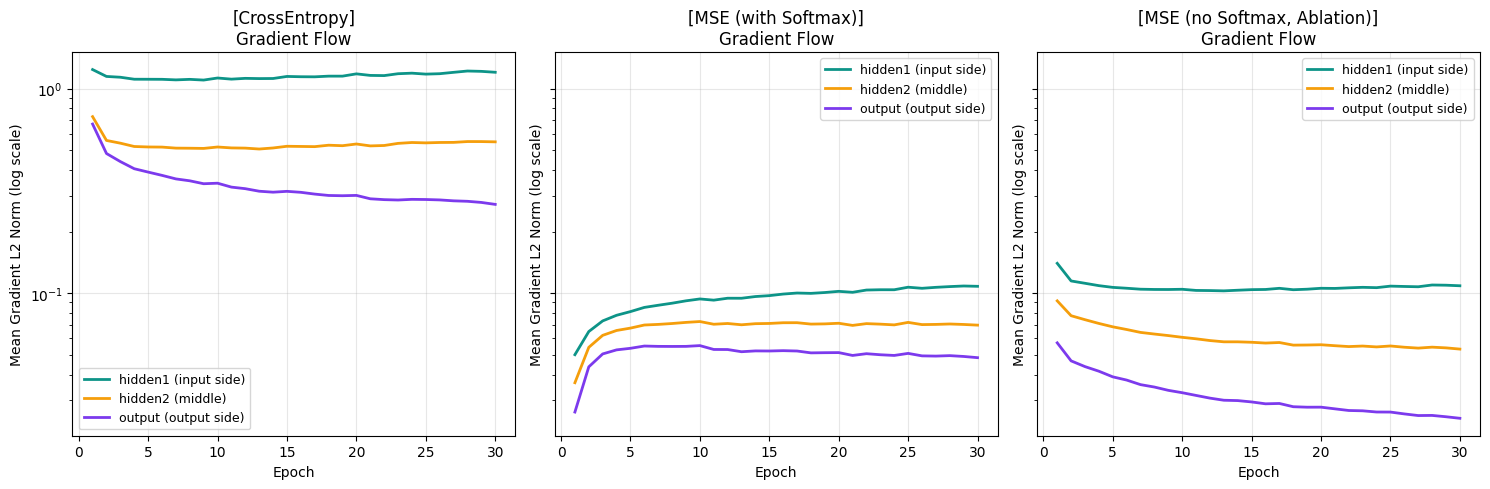


[Gradient norm ratio at final epoch (input side / output side)]
  CrossEntropy                    : 4.4257e+00
  MSE (with Softmax)              : 2.2333e+00
  MSE (no Softmax, Ablation)      : 4.4459e+00

Note: 비율이 작을수록 입력 측 레이어에 gradient 가 잘 전달되지 않는 것 (Vanishing 신호)


In [ ]:
fig, axes = plt.subplots(1, len(loss_modes_to_run),
                          figsize=(5 * len(loss_modes_to_run), 5),
                          sharey=True)

for col, mode in enumerate(loss_modes_to_run):
    log = all_logs[mode]
    axes[col].plot(ep, log.grad_norms_h1,  label='hidden1 (input side)',  color='#0D9488', linewidth=2)
    axes[col].plot(ep, log.grad_norms_h2,  label='hidden2 (middle)',      color='#F59E0B', linewidth=2)
    axes[col].plot(ep, log.grad_norms_out, label='output (output side)',   color='#7C3AED', linewidth=2)
    axes[col].set_yscale('log')  # 로그 스케일로 동적 범위 압축
    axes[col].set_xlabel('Epoch')
    axes[col].set_ylabel('Mean Gradient L2 Norm (log scale)')
    axes[col].set_title(f'[{mode_display_names[mode]}]\nGradient Flow')
    axes[col].legend(fontsize=9); axes[col].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# 학습 마지막 시점 gradient norm 비율 (입력 측 / 출력 측)
# 비율이 작을수록 Gradient Vanishing 신호
print('\n[Gradient norm ratio at final epoch (input side / output side)]')
for mode in loss_modes_to_run:
    log = all_logs[mode]
    ratio = log.grad_norms_h1[-1] / (log.grad_norms_out[-1] + 1e-12)
    print(f'  {mode_display_names[mode]:<32}: {ratio:.4e}')
print('\nNote: 비율이 작을수록 입력 측 레이어에 gradient 가 잘 전달되지 않는 것 (Vanishing 신호)')

### 13-4) 학습 초기 vs 후반의 Gradient 분포 비교 (해설질문 A-3)

출력층(logits) 레이어의 gradient 값 분포를 학습 **초기/후반** 두 시점에 대해 비교.  
CCE 는 초기에 큰 gradient 로 빠르게 학습하고, MSE 는 gradient 크기 자체가 작게 시작·유지된다.

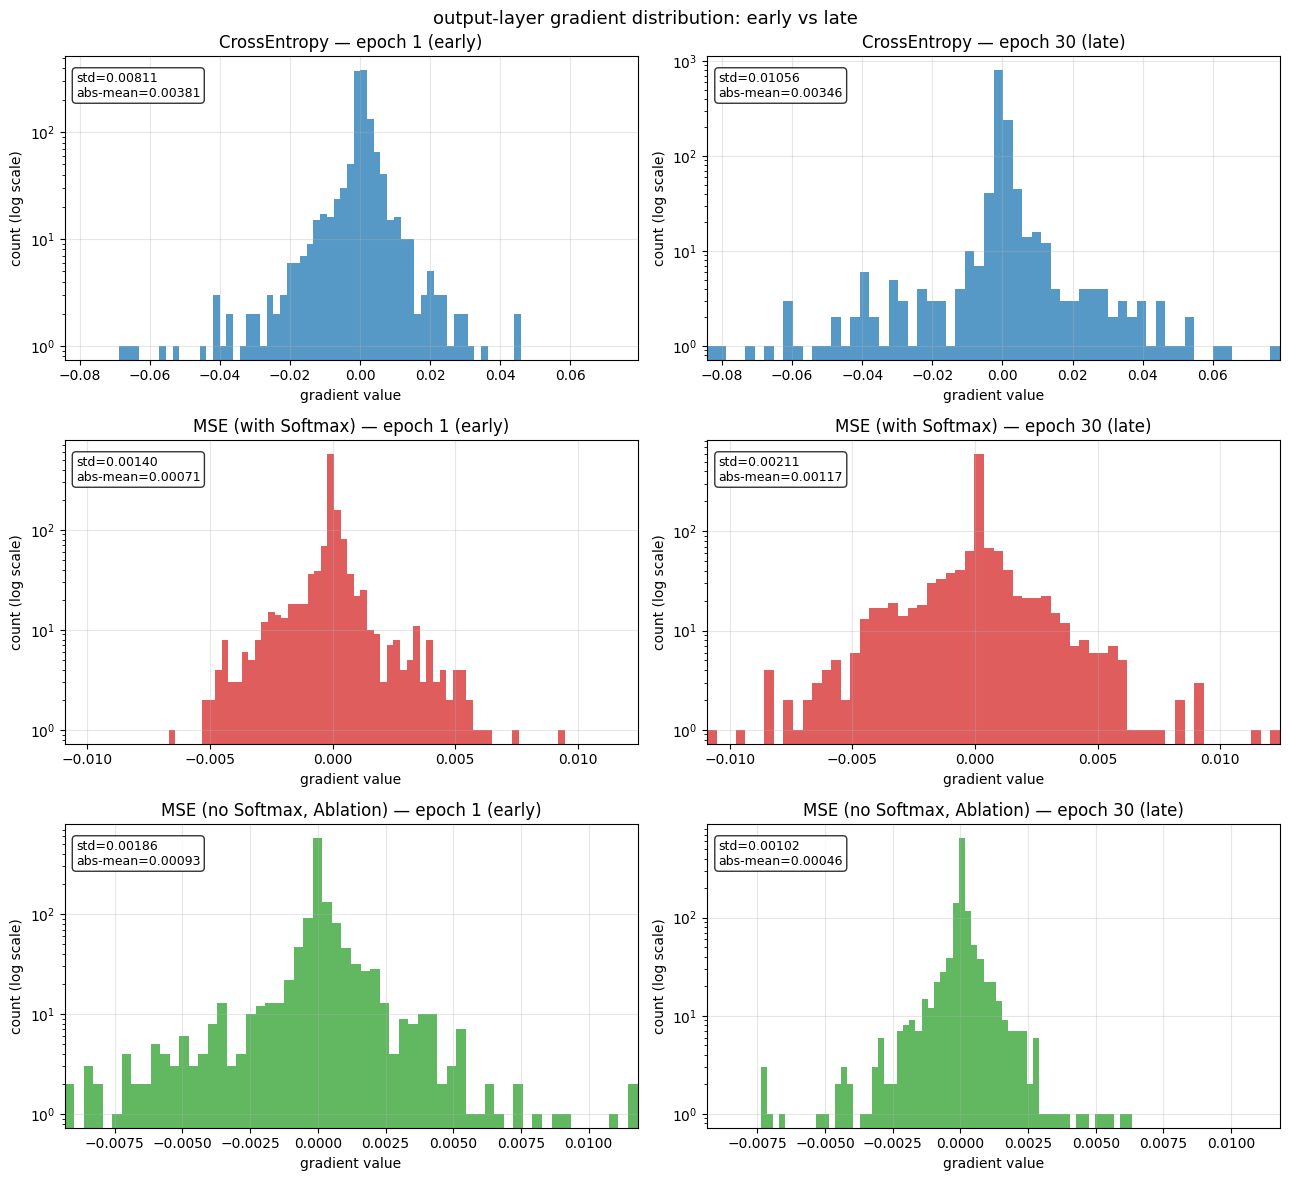


Cond          Epoch     grad std     abs-mean
---------------------------------------------
CCE               1     0.008112     0.003810
CCE              30     0.010561     0.003460
MSE-SM            1     0.001401     0.000714
MSE-SM           30     0.002107     0.001172
MSE-noSM          1     0.001860     0.000932
MSE-noSM         30     0.001016     0.000463


In [ ]:
fig, axes = plt.subplots(len(loss_modes_to_run), 2, figsize=(13, 12))
colors = {'ce': 'tab:blue', 'mse_softmax': 'tab:red', 'mse_raw': 'tab:green'}

for row, mode in enumerate(loss_modes_to_run):
    snaps = all_logs[mode].grad_snapshots
    items = sorted(snaps.items())    # [(1, vals), (30, vals)]
    for col, (e, vals) in enumerate(items):
        ax  = axes[row][col]
        tag = 'early' if col == 0 else 'late'
        ax.hist(vals, bins=60, color=colors[mode], alpha=0.75)
        ax.set_yscale('log')
        ax.set_title(f'{mode_display_names[mode]} — epoch {e} ({tag})')
        ax.set_xlabel('gradient value'); ax.set_ylabel('count (log scale)')
        ax.grid(alpha=0.3)
        ax.text(0.02, 0.95,
                f'std={vals.std():.5f}\nabs-mean={np.abs(vals).mean():.5f}',
                transform=ax.transAxes, va='top', fontsize=9,
                bbox=dict(boxstyle='round', fc='white', alpha=0.8))
    # 동일 손실함수의 두 subplot 은 x 축 공유
    x_min = min(snaps[min(snaps)].min(), snaps[max(snaps)].min())
    x_max = max(snaps[min(snaps)].max(), snaps[max(snaps)].max())
    axes[row][0].set_xlim(x_min, x_max)
    axes[row][1].set_xlim(x_min, x_max)

plt.suptitle('output-layer gradient distribution: early vs late', fontsize=13)
plt.tight_layout()
plt.show()

print(f"\n{'Cond':<12} {'Epoch':>6} {'grad std':>12} {'abs-mean':>12}")
print('-'*45)
for name, mode in [('CCE', 'ce'), ('MSE-SM', 'mse_softmax'), ('MSE-noSM', 'mse_raw')]:
    for e, vals in sorted(all_logs[mode].grad_snapshots.items()):
        print(f'{name:<12} {e:>6} {vals.std():>12.6f} {np.abs(vals).mean():>12.6f}')

### 13-5) Layer 별 Activation 분포 변화 (공통질문 3번)

학습 초반/중반/후반 시점에서 hidden layer ReLU 출력 분포를 히스토그램으로 비교.  
학습이 진행될수록 zero ratio 가 증가하는 **희소(sparse)한 구조**로 수렴하는 과정을 확인한다.

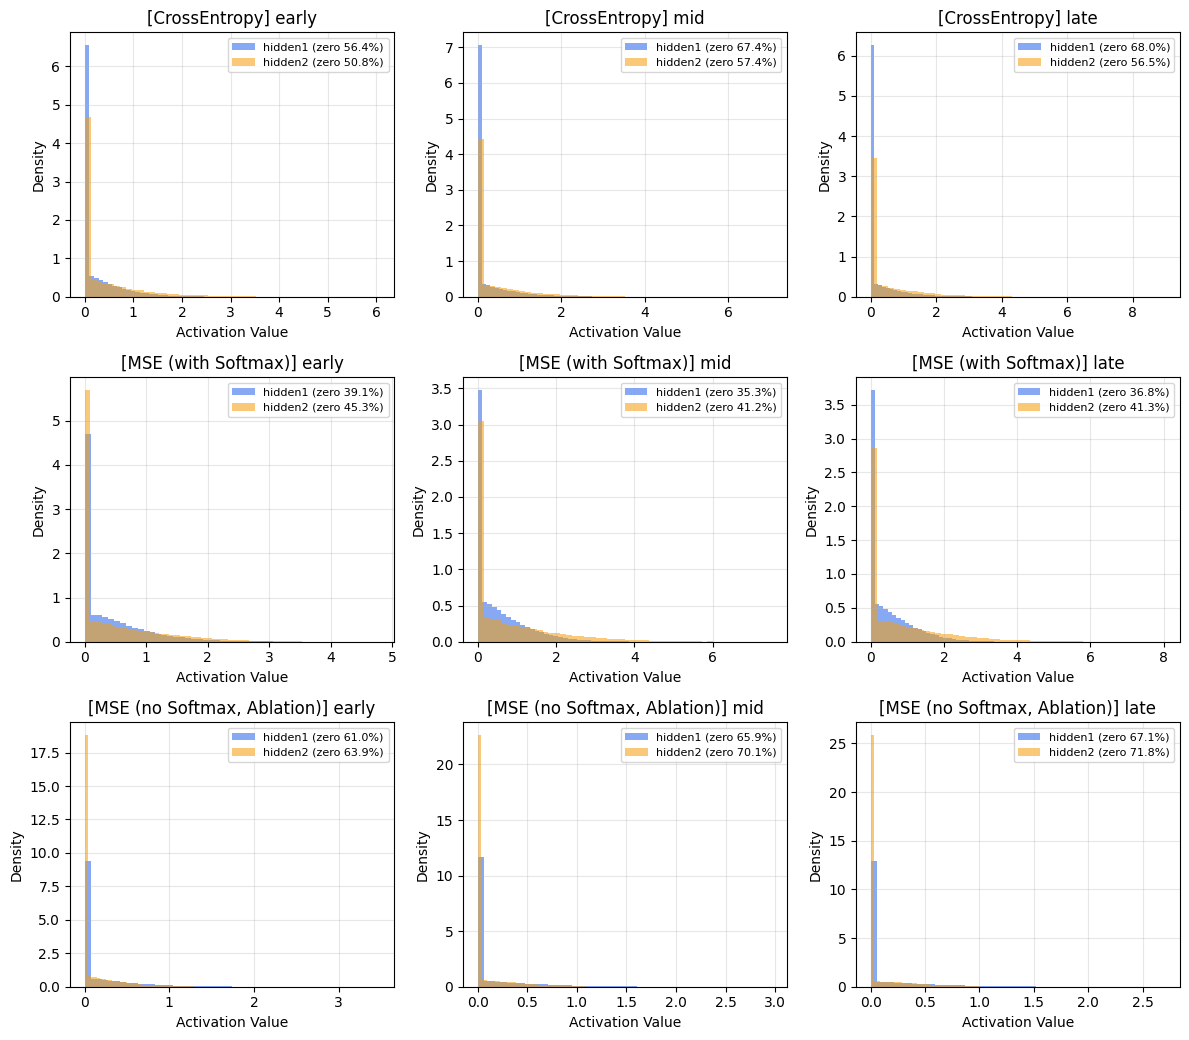


Cond           Layer        Stage     Mean      Std    Zero%
----------------------------------------------------------
CrossEntropy   hidden1      early   0.2478   0.4379    56.4%
CrossEntropy   hidden2      early   0.3972   0.6567    50.8%
CrossEntropy   hidden1        mid   0.2162   0.4610    67.4%
CrossEntropy   hidden2        mid   0.3850   0.6886    57.4%
CrossEntropy   hidden1       late   0.2391   0.5209    68.0%
CrossEntropy   hidden2       late   0.4757   0.8429    56.5%
MSE (with Sof  hidden1      early   0.4161   0.5582    39.1%
MSE (with Sof  hidden2      early   0.4871   0.6950    45.3%
MSE (with Sof  hidden1        mid   0.5291   0.6780    35.3%
MSE (with Sof  hidden2        mid   0.8047   1.1147    41.2%
MSE (with Sof  hidden1       late   0.4954   0.6398    36.8%
MSE (with Sof  hidden2       late   0.8083   1.1149    41.3%
MSE (no Softm  hidden1      early   0.1779   0.3372    61.0%
MSE (no Softm  hidden2      early   0.1212   0.2340    63.9%
MSE (no Softm  hidden1   

In [ ]:
stage_order  = ['early', 'mid', 'late']
layer_order  = ['hidden1', 'hidden2']
layer_colors = {'hidden1': '#2563EB', 'hidden2': '#F59E0B'}

fig, axes = plt.subplots(len(loss_modes_to_run), len(stage_order),
                          figsize=(4 * len(stage_order),
                                   3.5 * len(loss_modes_to_run)))

for row, mode in enumerate(loss_modes_to_run):
    recorder = all_activations[mode]
    for col, stage in enumerate(stage_order):
        ax = axes[row, col]
        captured = recorder.captured.get(stage, {})
        for layer_id in layer_order:
            if layer_id in captured:
                vals = captured[layer_id]
                zero_pct = (vals == 0).mean() * 100
                ax.hist(vals, bins=50, alpha=0.55,
                        color=layer_colors[layer_id], density=True,
                        label=f'{layer_id} (zero {zero_pct:.1f}%)')
        ax.set_title(f'[{mode_display_names[mode]}] {stage}')
        ax.set_xlabel('Activation Value'); ax.set_ylabel('Density')
        ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# 정량 요약
print(f"\n{'Cond':<14} {'Layer':<10} {'Stage':>7} {'Mean':>8} {'Std':>8} {'Zero%':>8}")
print('-'*58)
for mode in loss_modes_to_run:
    recorder = all_activations[mode]
    for stage in stage_order:
        captured = recorder.captured.get(stage, {})
        for layer in layer_order:
            v = captured.get(layer, np.array([]))
            if len(v) == 0:
                continue
            zero_r = (v == 0).mean() * 100
            print(f'{mode_display_names[mode][:13]:<14} {layer:<10} {stage:>7} '
                  f'{v.mean():>8.4f} {v.std():>8.4f} {zero_r:>7.1f}%')

### 13-6) Dead Neuron ratio 히트맵 (평가기준 3 충족)

각 레이어의 zero ratio 를 히트맵으로 시각화. 색이 진할수록 비활성(dead) 뉴런이 많음.

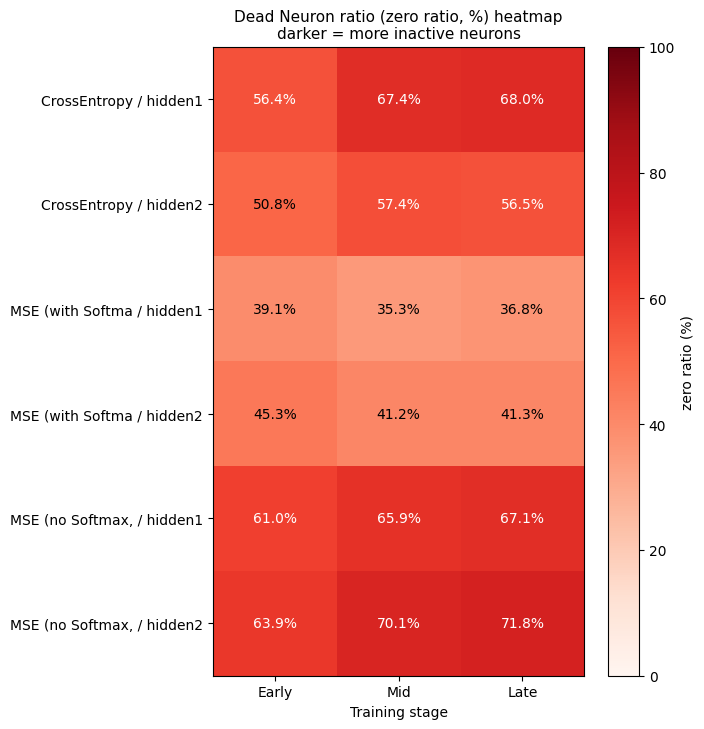


[Dead Neuron ratio change summary]
  CrossEntropy / hidden1              : early  56.4% -> late  68.0% (delta +11.6%p)
  CrossEntropy / hidden2              : early  50.8% -> late  56.5% (delta +5.7%p)
  MSE (with Softma / hidden1          : early  39.1% -> late  36.8% (delta -2.3%p)
  MSE (with Softma / hidden2          : early  45.3% -> late  41.3% (delta -4.0%p)
  MSE (no Softmax, / hidden1          : early  61.0% -> late  67.1% (delta +6.2%p)
  MSE (no Softmax, / hidden2          : early  63.9% -> late  71.8% (delta +7.9%p)


In [ ]:
row_labels  = []
zero_matrix = []

for mode in loss_modes_to_run:
    recorder = all_activations[mode]
    for layer in layer_order:
        row_labels.append(f'{mode_display_names[mode][:16]} / {layer}')
        row = [recorder.zero_ratio(stage, layer) for stage in stage_order]
        zero_matrix.append(row)

zero_matrix = np.array(zero_matrix)

fig, ax = plt.subplots(figsize=(7, 0.9 * len(row_labels) + 2))
im = ax.imshow(zero_matrix, cmap='Reds', aspect='auto', vmin=0, vmax=100)

ax.set_xticks(range(len(stage_order)))
ax.set_xticklabels([s.capitalize() for s in stage_order])
ax.set_yticks(range(len(row_labels)))
ax.set_yticklabels(row_labels)
ax.set_xlabel('Training stage')
ax.set_title('Dead Neuron ratio (zero ratio, %) heatmap\ndarker = more inactive neurons', fontsize=11)

for i in range(zero_matrix.shape[0]):
    for j in range(zero_matrix.shape[1]):
        val = zero_matrix[i, j]
        ax.text(j, i, f'{val:.1f}%', ha='center', va='center',
                color='white' if val > 55 else 'black', fontsize=10)

cbar = fig.colorbar(im, ax=ax)
cbar.set_label('zero ratio (%)')
plt.tight_layout()
plt.show()

print('\n[Dead Neuron ratio change summary]')
for i, label in enumerate(row_labels):
    deltas = zero_matrix[i]
    print(f'  {label:<36}: '
          f'early {deltas[0]:5.1f}% -> late {deltas[-1]:5.1f}% '
          f'(delta {deltas[-1] - deltas[0]:+.1f}%p)')

## 15) 해설 및 분석

본 노트북은 실험 코드와 실행 결과(그래프, 정량 지표)에 집중하며,  
공통질문 / 실험 A 전용 질문에 대한 상세 해설 및 결론·개선 사항은  
**별도 제출 보고서 PDF**에 정리한다.

> **보고서에서 다루는 항목**
> - 공통질문 Q1~Q4 (학습곡선·Loss/Acc 불균형·Activation 분포 변화·Gradient Flow)
> - 실험 A 전용 Q1~Q4 (MSE vs CE 학습 속도 차이, Gradient Vanishing 완화 메커니즘,  
>   학습 초기/후반 gradient 분포 차이, softmax 미적용 시 학습 불가 원인)
> - 결론 및 개선 방향 (Xavier/He 초기화, lr 스케줄러, Batch Normalization 등)

본 노트북에서 산출된 시각화와 정량 지표는 위 보고서의 근거 자료로 인용된다.
